# NOTEBOOK EXAMPLE 

In [28]:
#few
import few 
from few.trajectory.inspiral import EMRIInspiral
from few.waveform import GenerateEMRIWaveform
from few.trajectory.ode import KerrEccEqFlux
from few.utils.geodesic import get_separatrix

#mew
from mew import KerrCircEqFluxScalar

#standard scientific python libraries 
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


## TRAJECTORIES

In [30]:
# Small buffer added to the semi-latus rectum to avoid starting exactly at the separatrix
p_buffer = 0.01

# GR model: set up EMRI inspiral using Kerr eccentric fluxes
traj_Kerr_GR = EMRIInspiral(func=KerrEccEqFlux)

# Scalar model: set up EMRI inspiral with scalar flux
traj_Kerr_Scalar = EMRIInspiral(func=KerrCircEqFluxScalar, integrate_constants_of_motion=False)

### BACKWARD INTEGRATION (PROGRADE ORBITS)

In [31]:
# Define system parameters
M = 1e6
mu = 10
a = 0.9
e0 = 0.0
x_I0 = 1.0
Tobs = 2

print("System parameters:")
print(f"M     = {M}")
print(f"mu    = {mu}")
print(f"a     = {a}")
print(f"e0    = {e0}")
print(f"x_I0  = {x_I0}")
print(f"Tobs  = {Tobs} yr\n")


# Compute separatrix (innermost stable orbit) for these parameters
p_sep = get_separatrix(a, e0, x_I0)
print(f"Separatrix (p_sep) = {p_sep}\n")

emri_injection_params_GR = [
    M,
    mu,
    a,
    p_sep + p_buffer,
    e0,
    x_I0,
]

# Compute backward inspiral using the GR model
t_back_GR, p_back_GR, e_back_GR, x_back_GR, Phi_phi_back_GR, Phi_r_back_GR, Phi_theta_back_GR = traj_Kerr_GR(*emri_injection_params_GR, T=Tobs, integrate_backwards=True)
p0_GR = p_back_GR[-1]
print("p0 with GR model = ", p0_GR)


# Compute backward inspiral using the Scalar model with d = 0
d = 0.0
Lambda_s0 = d**2
add_params_s0 = [Lambda_s0]

t_back_s0, p_back_s0, e_back_s0, x_back_s0, Phi_phi_back_s0, Phi_r_back_s0, Phi_theta_back_s0 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s0, T=Tobs, integrate_backwards=True)
p0_s0 = p_back_s0[-1]
print(f"p0 with Scalar model when d = {d}: {p0_s0}")

# Compute backward inspiral using the Scalar model with d = 0.1
d = 0.1
Lambda_s01 = d**2
add_params_s01 = [Lambda_s01]

t_back_s01, p_back_s01, e_back_s01, x_back_s01, Phi_phi_back_s01, Phi_r_back_s01, Phi_theta_back_s01 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s01, T=Tobs, integrate_backwards=True)
p0_s01 = p_back_s01[-1]
print(f"p0 with Scalar model when d = {d}: {p0_s01}")

System parameters:
M     = 1000000.0
mu    = 10
a     = 0.9
e0    = 0.0
x_I0  = 1.0
Tobs  = 2 yr

Separatrix (p_sep) = 2.320883041761887

p0 with GR model =  8.556028045419255
p0 with Scalar model when d = 0.0: 8.556028045419255
p0 with Scalar model when d = 0.1: 8.558003034843974


In [32]:
# Create interpolating functions
interp_GR   = interp1d(t_back_GR, Phi_phi_back_GR)
interp_s0   = interp1d(t_back_s0, Phi_phi_back_s0)
interp_s01  = interp1d(t_back_s01, Phi_phi_back_s01)

# Time at start in seconds
t_f_GR_sec   = t_back_GR[0]
t_f_s0_sec   = t_back_s0[0]
t_f_s01_sec  = t_back_s01[0]

# Convert to days
t_f_GR_days  = t_f_GR_sec / 86400
t_f_s0_days  = t_f_s0_sec / 86400
t_f_s01_days = t_f_s01_sec / 86400

# Print times
print(f"Start time (GR)   = {t_f_GR_sec:.2f} s ≈ {t_f_GR_days:.4f} days")
print(f"Start time (s0)   = {t_f_s0_sec:.2f} s ≈ {t_f_s0_days:.4f} days")
print(f"Start time (s01)  = {t_f_s01_sec:.2f} s ≈ {t_f_s01_days:.4f} days\n")

# Interpolated phases
phi_GR  = interp_GR(t_f_GR_sec)
phi_s0  = interp_s0(t_f_s0_sec)
phi_s01 = interp_s01(t_f_s01_sec)

print(f"Interpolated phase at start (GR)   = {phi_GR:.6f}")
print(f"Interpolated phase at start (s0)   = {phi_s0:.6f}")
print(f"Interpolated phase at start (s01)  = {phi_s01:.6f}\n")

# Compute phase differences
delta_phi_s01 = 2 * (phi_GR - interp_s01(t_f_GR_sec))
delta_phi_s0  = 2 * (phi_GR - interp_s0(t_f_GR_sec))

print(f"Phase difference GR - s01 = {delta_phi_s01:.6f} rad")
print(f"Phase difference GR - s0  = {delta_phi_s0:.6f} rad")

Start time (GR)   = 0.00 s ≈ 0.0000 days
Start time (s0)   = 0.00 s ≈ 0.0000 days
Start time (s01)  = 0.00 s ≈ 0.0000 days

Interpolated phase at start (GR)   = 745527.039603
Interpolated phase at start (s0)   = 745527.039603
Interpolated phase at start (s01)  = 745355.354785

Phase difference GR - s01 = 343.369636 rad
Phase difference GR - s0  = 0.000000 rad


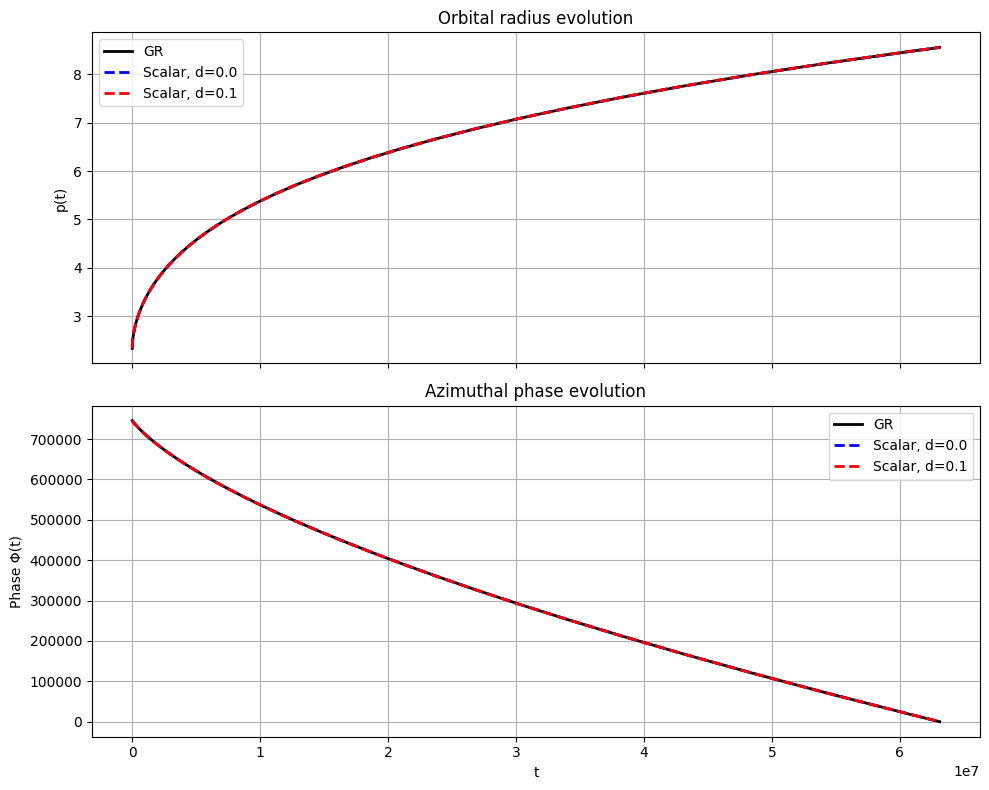

In [33]:
# Create figure with 2 subplots 
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot p(t) in the first subplot 
ax1 = axes[0]

# GR model
ax1.plot(t_back_GR, p_back_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
ax1.plot(t_back_s0, p_back_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
d = 0.1
ax1.plot(t_back_s01, p_back_s01, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

ax1.set_ylabel("p(t)")
ax1.set_title("Orbital radius evolution")
ax1.legend()
ax1.grid(True)

# Plot phase Phi(t) in the second subplot
ax2 = axes[1]

# GR model
ax2.plot(t_back_GR, Phi_phi_back_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
ax2.plot(t_back_s0, Phi_phi_back_s0, label=f"Scalar, d={0.0}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
ax2.plot(t_back_s01, Phi_phi_back_s01, label=f"Scalar, d={0.1}", linestyle="--", color="red", linewidth=2)

ax2.set_xlabel("t")
ax2.set_ylabel("Phase Φ(t)")
ax2.set_title("Azimuthal phase evolution")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### FORWARD INTEGRATION (PROGRADE ORBITS)

In [34]:
# Define system parameters
M = 1e6
mu = 10
a = 0.9
e0 = 0.0
x_I0 = 1.0
Tobs = 2.0 

print("System parameters:")
print(f"M     = {M}")
print(f"mu    = {mu}")
print(f"a     = {a}")
print(f"e0    = {e0}")
print(f"x_I0  = {x_I0}")
print(f"Tobs  = {Tobs} yr\n")

p0 = 10.0

emri_injection_params_GR = [
    M,
    mu,
    a,
    p0,
    e0,
    x_I0,
]

# Compute backward inspiral using the GR model
t_GR, p_GR, e_GR, x_GR, Phi_phi_GR, Phi_r_GR, Phi_theta_GR = traj_Kerr_GR(*emri_injection_params_GR, T=Tobs, integrate_backwards=False)
p_fin = p_GR[-1]
print("p_fin with GR model = ", p_fin)

# Compute backward inspiral using the scalar model with d = 0
d = 0.0
Lambda_s0 = d**2
add_params_s0 = [Lambda_s0]

t_s0, p_s0, e_s0, x_s0, Phi_phi_s0, Phi_r_s0, Phi_theta_s0 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s0, T=Tobs, integrate_backwards=False)
p_fin = p_s0[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

# Compute backward inspiral using the scalar model with d = 0.1
d = 0.1
Lambda_s01 = d**2
add_params_s01 = [Lambda_s01]
t_s01, p_s01, e_s01, x_s01, Phi_phi_s01, Phi_r_s01, Phi_theta_s01 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s01, T=Tobs, integrate_backwards=False)
p_fin = p_s01[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

System parameters:
M     = 1000000.0
mu    = 10
a     = 0.9
e0    = 0.0
x_I0  = 1.0
Tobs  = 2.0 yr

p_fin with GR model =  8.159294282681522
p_fin with Scalar model when d = 0.0: 8.159294282681522
p_fin with Scalar model when d = 0.1: 8.156218416634797


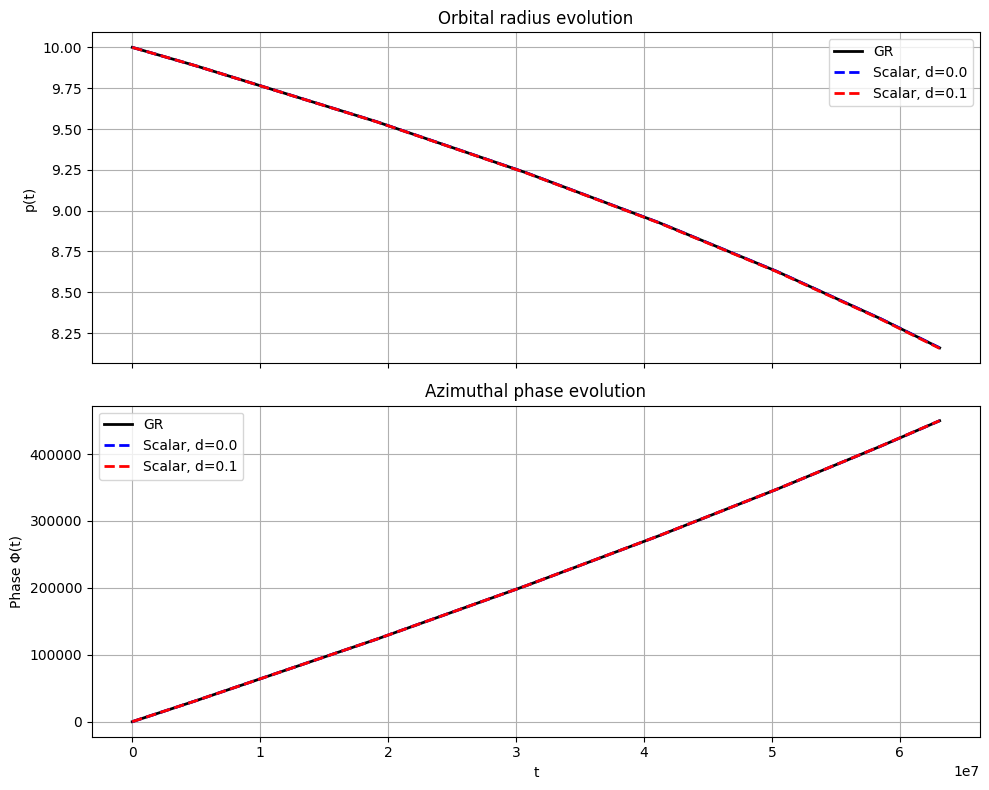

In [35]:
# Create figure with 2 subplots 
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot p(t) in the first subplot 
ax1 = axes[0]

# GR model
ax1.plot(t_GR, p_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
ax1.plot(t_s0, p_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
d = 0.1
ax1.plot(t_s01, p_s01, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

ax1.set_ylabel("p(t)")
ax1.set_title("Orbital radius evolution")
ax1.legend()
ax1.grid(True)

# Plot phase Φ(t) in the second subplot
ax2 = axes[1]


# GR model
ax2.plot(t_GR, Phi_phi_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
ax2.plot(t_s0, Phi_phi_s0, label=f"Scalar, d={0.0}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
ax2.plot(t_s01, Phi_phi_s01, label=f"Scalar, d={0.1}", linestyle="--", color="red", linewidth=2)

ax2.set_xlabel("t")
ax2.set_ylabel("Phase Φ(t)")
ax2.set_title("Azimuthal phase evolution")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### BACKWARD INTEGRATION (RETROGRADE ORBITS)

In [36]:
# Define system parameters
M = 1e6
mu = 10
a = -0.9
e0 = 0.0
x_I0 = 1.0
Tobs = 2

print("System parameters:")
print(f"M     = {M}")
print(f"mu    = {mu}")
print(f"a     = {a}")
print(f"e0    = {e0}")
print(f"x_I0  = {x_I0}")
print(f"Tobs  = {Tobs} yr\n")


# Compute separatrix (innermost stable orbit) for these parameters
p_sep = get_separatrix(a, e0, x_I0)
print(f"Separatrix (p_sep) = {p_sep}\n")

emri_injection_params_GR = [
    M,
    mu,
    a,
    p_sep + p_buffer,
    e0,
    x_I0,
]

# Compute backward inspiral using the GR model
t_back_GR, p_back_GR, e_back_GR, x_back_GR, Phi_phi_back_GR, Phi_r_back_GR, Phi_theta_back_GR = traj_Kerr_GR(*emri_injection_params_GR, T=Tobs, integrate_backwards=True)
p0_GR = p_back_GR[-1]
print("p0 with GR model = ", p0_GR)


# Compute backward inspiral using the Scalar model with d = 0
d = 0.0
Lambda_s0 = d**2
add_params_s0 = [Lambda_s0]

t_back_s0, p_back_s0, e_back_s0, x_back_s0, Phi_phi_back_s0, Phi_r_back_s0, Phi_theta_back_s0 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s0, T=Tobs, integrate_backwards=True)
p0_s0 = p_back_s0[-1]
print(f"p0 with Scalar model when d = {d}: {p0_s0}")

# Compute backward inspiral using the Scalar model with d = 0.1
d = 0.1
Lambda_s01 = d**2
add_params_s01 = [Lambda_s01]

t_back_s01, p_back_s01, e_back_s01, x_back_s01, Phi_phi_back_s01, Phi_r_back_s01, Phi_theta_back_s01 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s01, T=Tobs, integrate_backwards=True)
p0_s01 = p_back_s01[-1]
print(f"p0 with Scalar model when d = {d}: {p0_s01}")

System parameters:
M     = 1000000.0
mu    = 10
a     = -0.9
e0    = 0.0
x_I0  = 1.0
Tobs  = 2 yr

Separatrix (p_sep) = 8.717352279606489

p0 with GR model =  12.581314627943952
p0 with Scalar model when d = 0.0: 12.581314627943952
p0 with Scalar model when d = 0.1: 12.583586789568063


In [37]:
# Create interpolating functions
interp_GR   = interp1d(t_back_GR, Phi_phi_back_GR)
interp_s0   = interp1d(t_back_s0, Phi_phi_back_s0)
interp_s01  = interp1d(t_back_s01, Phi_phi_back_s01)

# Time at start in seconds
t_f_GR_sec   = t_back_GR[0]
t_f_s0_sec   = t_back_s0[0]
t_f_s01_sec  = t_back_s01[0]

# Convert to days
t_f_GR_days  = t_f_GR_sec / 86400
t_f_s0_days  = t_f_s0_sec / 86400
t_f_s01_days = t_f_s01_sec / 86400

# Print times
print(f"Start time (GR)   = {t_f_GR_sec:.2f} s ≈ {t_f_GR_days:.4f} days")
print(f"Start time (s0)   = {t_f_s0_sec:.2f} s ≈ {t_f_s0_days:.4f} days")
print(f"Start time (s01)  = {t_f_s01_sec:.2f} s ≈ {t_f_s01_days:.4f} days\n")

# Interpolated phases
phi_GR  = interp_GR(t_f_GR_sec)
phi_s0  = interp_s0(t_f_s0_sec)
phi_s01 = interp_s01(t_f_s01_sec)

print(f"Interpolated phase at start (GR)   = {phi_GR:.6f}")
print(f"Interpolated phase at start (s0)   = {phi_s0:.6f}")
print(f"Interpolated phase at start (s01)  = {phi_s01:.6f}\n")

# Compute phase differences
delta_phi_s01 = 2 * (phi_GR - interp_s01(t_f_GR_sec))
delta_phi_s0  = 2 * (phi_GR - interp_s0(t_f_GR_sec))

print(f"Phase difference GR - s01 = {delta_phi_s01:.6f} rad")
print(f"Phase difference GR - s0  = {delta_phi_s0:.6f} rad")

Start time (GR)   = 0.00 s ≈ 0.0000 days
Start time (s0)   = 0.00 s ≈ 0.0000 days
Start time (s01)  = 0.00 s ≈ 0.0000 days

Interpolated phase at start (GR)   = 344616.444503
Interpolated phase at start (s0)   = 344616.444503
Interpolated phase at start (s01)  = 344549.945785

Phase difference GR - s01 = 132.997436 rad
Phase difference GR - s0  = 0.000000 rad


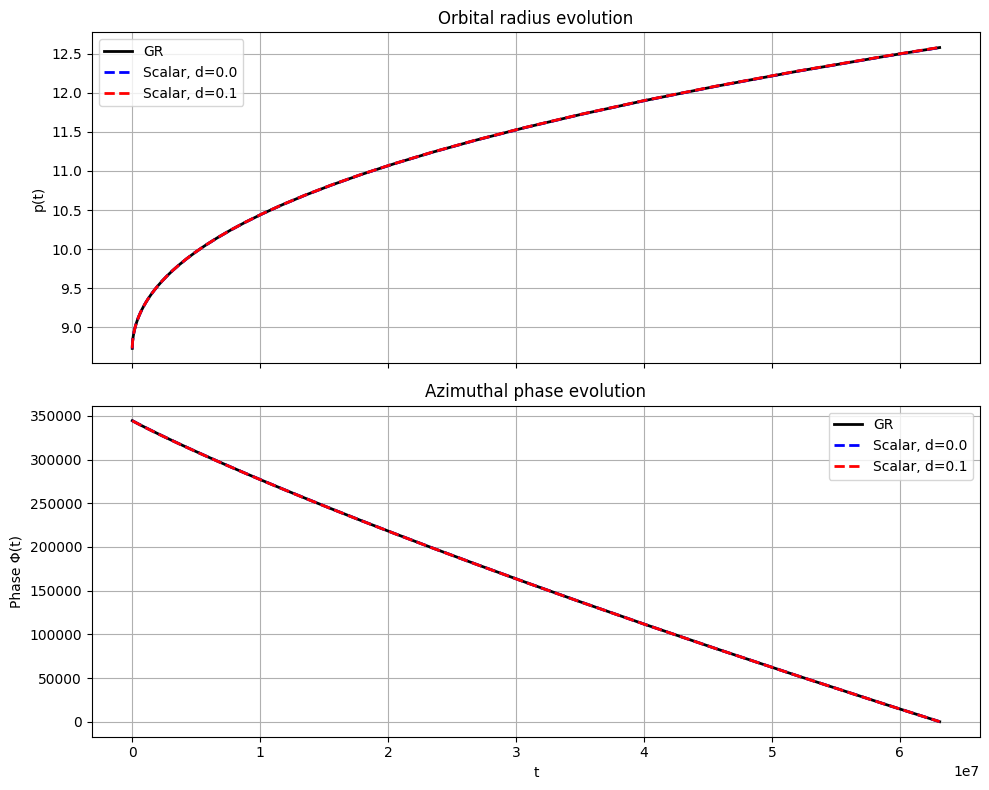

In [38]:
# Create figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot p(t) in the first subplot
ax1 = axes[0]

# GR model
ax1.plot(t_back_GR, p_back_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
ax1.plot(t_back_s0, p_back_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
d = 0.1
ax1.plot(t_back_s01, p_back_s01, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

ax1.set_ylabel("p(t)")
ax1.set_title("Orbital radius evolution")
ax1.legend()
ax1.grid(True)

# Plot phase Φ(t) in the second subplot
ax2 = axes[1]

# GR model
ax2.plot(t_back_GR, Phi_phi_back_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
ax2.plot(t_back_s0, Phi_phi_back_s0, label=f"Scalar, d={0.0}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
ax2.plot(t_back_s01, Phi_phi_back_s01, label=f"Scalar, d={0.1}", linestyle="--", color="red", linewidth=2)

ax2.set_xlabel("t")
ax2.set_ylabel("Phase Φ(t)")
ax2.set_title("Azimuthal phase evolution")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### FORWARD INTEGRATION (RETROGRADE ORBITS)

In [39]:
# Define system parameters
M = 1e6
mu = 10
a = - 0.9
e0 = 0.0
x_I0 = 1.0
Tobs = 2.0 

print("System parameters:")
print(f"M     = {M}")
print(f"mu    = {mu}")
print(f"a     = {a}")
print(f"e0    = {e0}")
print(f"x_I0  = {x_I0}")
print(f"Tobs  = {Tobs} yr\n")

p0 = 10.0

emri_injection_params_GR = [
    M,
    mu,
    a,
    p0,
    e0,
    x_I0,
]

# Compute backward inspiral using the GR model
t_GR, p_GR, e_GR, x_GR, Phi_phi_GR, Phi_r_GR, Phi_theta_GR = traj_Kerr_GR(*emri_injection_params_GR, T=Tobs, integrate_backwards=False)
p_fin = p_GR[-1]
print("p_fin with GR model = ", p_fin)

# Compute backward inspiral using the scalar model with d = 0
d = 0.0
Lambda_s0 = d**2
add_params_s0 = [Lambda_s0]

t_s0, p_s0, e_s0, x_s0, Phi_phi_s0, Phi_r_s0, Phi_theta_s0 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s0, T=Tobs, integrate_backwards=False)
p_fin = p_s0[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

# Compute backward inspiral using the scalar model with d = 0.1
d = 0.1
Lambda_s01 = d**2
add_params_s01 = [Lambda_s01]
t_s01, p_s01, e_s01, x_s01, Phi_phi_s01, Phi_r_s01, Phi_theta_s01 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s01, T=Tobs, integrate_backwards=False)
p_fin = p_s01[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

System parameters:
M     = 1000000.0
mu    = 10
a     = -0.9
e0    = 0.0
x_I0  = 1.0
Tobs  = 2.0 yr

p_fin with GR model =  8.719352279598098
p_fin with Scalar model when d = 0.0: 8.719352279598098
p_fin with Scalar model when d = 0.1: 8.719352279598173


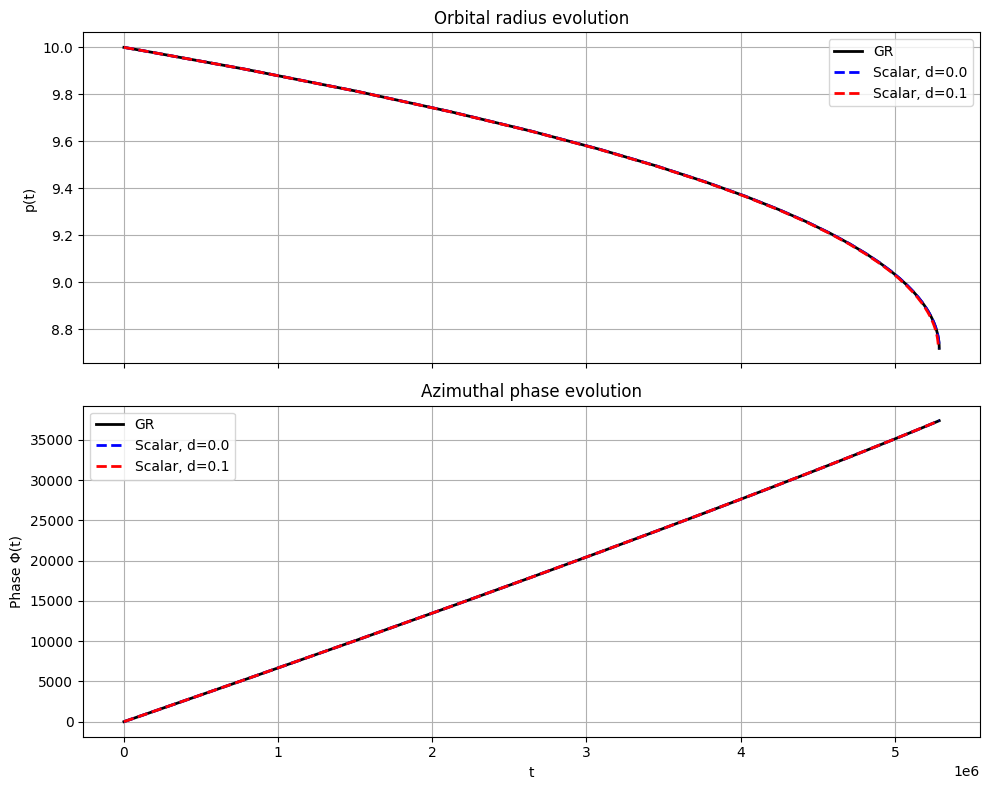

In [40]:
# Create figure with 2 subplots 
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot p(t) in the first subplot 
ax1 = axes[0]

# GR model
ax1.plot(t_GR, p_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
ax1.plot(t_s0, p_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
d = 0.1
ax1.plot(t_s01, p_s01, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

ax1.set_ylabel("p(t)")
ax1.set_title("Orbital radius evolution")
ax1.legend()
ax1.grid(True)

# Plot phase Φ(t) in the second subplot
ax2 = axes[1]


# GR model
ax2.plot(t_GR, Phi_phi_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
ax2.plot(t_s0, Phi_phi_s0, label=f"Scalar, d={0.0}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.1
ax2.plot(t_s01, Phi_phi_s01, label=f"Scalar, d={0.1}", linestyle="--", color="red", linewidth=2)

ax2.set_xlabel("t")
ax2.set_ylabel("Phase Φ(t)")
ax2.set_title("Azimuthal phase evolution")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## WAVEFORMS

In [41]:
# Define system parameters
M = 1e5
mu = 50
a = 0.9
e0 = 0.0
x_I0 = 1.0
Tobs = 1.0

print("System parameters:")
print(f"M     = {M}")
print(f"mu    = {mu}")
print(f"a     = {a}")
print(f"e0    = {e0}")
print(f"x_I0  = {x_I0}")
print(f"Tobs  = {Tobs} yr\n")


# Compute separatrix (innermost stable orbit) for these parameters
p_sep = get_separatrix(a, e0, x_I0)
print(f"Separatrix (p_sep) = {p_sep}\n")

emri_injection_params_GR = [
    M,
    mu,
    a,
    p_sep + p_buffer,
    e0,
    x_I0,
]

# Compute backward inspiral using the GR model
t_back_GR, p_back_GR, e_back_GR, x_back_GR, Phi_phi_back_GR, Phi_r_back_GR, Phi_theta_back_GR = traj_Kerr_GR(*emri_injection_params_GR, T=Tobs, integrate_backwards=True)
p0_GR = p_back_GR[-1]
print("p0 with GR model = ", p0_GR)


# Compute backward inspiral using the Scalar model with d = 0
d = 0.0
Lambda_s0 = d**2
add_params_s0 = [Lambda_s0]

t_back_s0, p_back_s0, e_back_s0, x_back_s0, Phi_phi_back_s0, Phi_r_back_s0, Phi_theta_back_s0 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s0, T=Tobs, integrate_backwards=True)
p0_s0 = p_back_s0[-1]
print(f"p0 with Scalar model when d = {d}: {p0_s0}")

# Compute backward inspiral using the Scalar model with d = 0.1
d = 0.1
Lambda_s01 = d**2
add_params_s01 = [Lambda_s01]

t_back_s01, p_back_s01, e_back_s01, x_back_s01, Phi_phi_back_s01, Phi_r_back_s01, Phi_theta_back_s01 = traj_Kerr_Scalar(*emri_injection_params_GR, *add_params_s01, T=Tobs, integrate_backwards=True)
p0_s01 = p_back_s01[-1]
print(f"p0 with Scalar model when d = {d}: {p0_s01}")


# Extrinsic parameters
qK = np.pi / 3   
phiK = np.pi / 3 
qS = np.pi / 3   
phiS = np.pi / 3 
dist = 1.0      

# Initial phases
Phi_phi0 = np.pi / 3
Phi_theta0 = 0.0
Phi_r0 = np.pi / 3

dt = 5.0    # time interval (seconds)

mode_selection_threshold = 1e-4  # relative threshold for mode inclusion

waveform_kwargs = {
    "T": Tobs,
    "dt": dt,
    "mode_selection_threshold": mode_selection_threshold,
}

System parameters:
M     = 100000.0
mu    = 50
a     = 0.9
e0    = 0.0
x_I0  = 1.0
Tobs  = 1.0 yr

Separatrix (p_sep) = 2.320883041761887

p0 with GR model =  35.19669323809141
p0 with Scalar model when d = 0.0: 35.19669323809141
p0 with Scalar model when d = 0.1: 35.23015220003428


In [42]:
emri_injection_params_GR = [
    M,
    mu,
    a,
    p0_GR,
    e0,
    x_I0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
]


inspiral_kwargs_GR = {
    'flux_output_convention':'pex',
    'func':KerrEccEqFlux
    }


# generate the TD signal for the GR model
Kerr_waveform_GR = GenerateEMRIWaveform(
        "FastKerrEccentricEquatorialFlux",
        sum_kwargs=dict(pad_output=True),
        inspiral_kwargs = inspiral_kwargs_GR,
        return_list=True,
    )


In [43]:
inspiral_kwargs_scalar = {
    'flux_output_convention':'pex',
    'func':KerrCircEqFluxScalar
    }

# generate the TD signal for the Scalar model
Kerr_waveform_scalar = GenerateEMRIWaveform(
        "FastKerrEccentricEquatorialFlux",
        sum_kwargs=dict(pad_output=True),
        inspiral_kwargs = inspiral_kwargs_scalar,
        return_list=True,
    )

In [44]:
Kerr_waveform_GR = Kerr_waveform_GR(*emri_injection_params_GR, **waveform_kwargs)

In [45]:
Kerr_waveform_s0 = Kerr_waveform_scalar(*emri_injection_params_GR, *add_params_s0, **waveform_kwargs)
Kerr_waveform_s01 = Kerr_waveform_scalar(*emri_injection_params_GR, *add_params_s01, **waveform_kwargs)

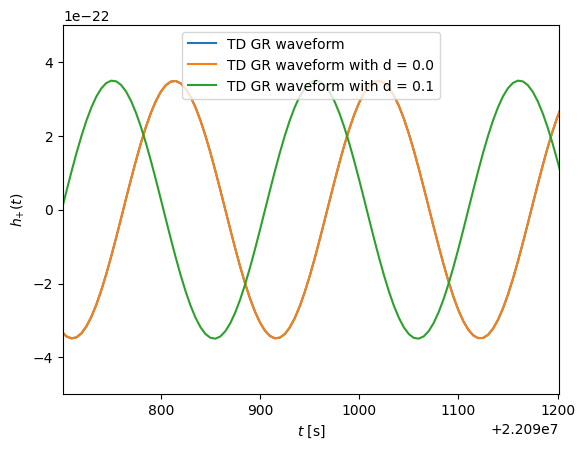

In [46]:
# Plot the waveforms in the time domain
plt.figure()

# GR model
time_array_GR = np.arange(0, len(Kerr_waveform_GR[0])) * dt
plt.plot(time_array_GR, Kerr_waveform_GR[0].real, label="TD GR waveform")

# Scalar model d = 0
time_array_s0 = np.arange(0, len(Kerr_waveform_s0[0])) * dt
plt.plot(time_array_s0, Kerr_waveform_s0[0].real, label="TD GR waveform with d = 0.0")

# Scalar model d = 0.1
time_array_s01 = np.arange(0, len(Kerr_waveform_s01[0])) * dt
plt.plot(time_array_s01, Kerr_waveform_s01[0].real, label="TD GR waveform with d = 0.1")


plt.ylabel(r"$h_{+}(t)$")
plt.xlabel(r"$t$ [s]")

t0 = time_array_GR[-1] * 0.7
space_t = 10e2
plt.xlim([t0, t0 + space_t / 2])
plt.ylim([-5e-22, 5e-22])
plt.legend(loc="upper center")
plt.show()

## FORBIDDEN REGIONS OF THE PARAMETER SPACE 

In [47]:
# If you set the eccentricity to a nonzero value, the class raises an error
M = 1e6
mu = 10.0
a = 0.9
d = 0.1
p0 = 10.0
x_I0 = 1.0
e0 = 0.1

t, p, e, x, Phi_phi, Phi_r, Phi_theta = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, T=Tobs, integrate_backwards=False)


ValueError: Eccentricity e must be zero for circular orbits.

In [ ]:
# If you set x_I0 to a value different from ±1, the class raises an error

M = 1e6
mu = 10.0
a = 0.9
d = 0.1
p0 = 10.0
x_I0 = 1.1
e0 = 0.0

t, p, e, x, Phi_phi, Phi_r, Phi_theta = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, T=Tobs, integrate_backwards=False)


ValueError: Interpolation: x out of bounds. Must be either 1 or -1.

In [ ]:
# If you set p0 to a value > 200, the class raises an error

M = 1e6
mu = 10.0
a = 0.9
d = 0.1
p0 = 202.0
x_I0 = 1.1
e0 = 0.0
t, p, e, x, Phi_phi, Phi_r, Phi_theta = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, T=Tobs, integrate_backwards=False)

ValueError: Interpolation: x out of bounds. Must be either 1 or -1.

In [ ]:
# If you set p0 < p_sep, the class raises an error

M = 1e6
mu = 10.0
a = 0.9
d = 0.1
p0 = 202.0
x_I0 = 1.1
e0 = 0.0

p_sep = get_separatrix(a, e0, x_I0)

p0 = p_sep - 0.01
t, p, e, x, Phi_phi, Phi_r, Phi_theta = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, T=Tobs, integrate_backwards=False)

ValueError: f(a) and f(b) must have different signs.